# **DIDP model**

In [1]:
%%writefile CVRP_single_dual_bound_DIDP_declaration.py
import sys
import os
import re
import numpy as np
import vrplib
import modified_didppy as m_dp

# ==========================================
# 2. Data Reading & Model Definition
# ==========================================

# Global variables to store current instance data (used by model creator)
current_num_locations = 0
current_num_vehicles = 0
current_capacity = 0
current_cust_demands = []
current_travel_cost = []

def read_formatted_data(file_path):
    """
    Reads a VRP file using vrplib and updates the global variables.
    """
    global current_num_locations, current_num_vehicles, current_capacity
    global current_cust_demands, current_travel_cost
    
    # Read instance
    # FIX: compute_edge_weights=True handles instances with coordinates but no edge weights
    instance = vrplib.read_instance(file_path, compute_edge_weights=True)
    
    # Extract Capacity & Dimensions
    current_capacity = float(instance['capacity'])
    current_num_locations = int(instance['dimension'])

    # Extract Demands (Includes depot at index 0 with demand 0)
    current_cust_demands = [float(x) for x in instance['demand']]

    # Extract/Compute Edge Weights
    # vrplib usually computes euclidean distance automatically in 'edge_weight'
    current_travel_cost = [[float(x) for x in row] for row in instance['edge_weight']]
    
    # Try to determine number of vehicles from comment or filename
    match_comment = re.search(r"No of trucks:\s*(\d+)", str(instance.get('comment', '')))
    match_name = re.search(r"-k(\d+)", os.path.basename(file_path))
    
    if match_comment:
        current_num_vehicles = int(match_comment.group(1))
    elif match_name:
        current_num_vehicles = int(match_name.group(1))
    else:
        # Fallback: Estimate or set a high number (e.g., N)
        current_num_vehicles = current_num_locations 

    return current_num_locations, current_num_vehicles, current_travel_cost, current_capacity, current_cust_demands

def creation_of_didp_model_function():
    """
    Creates the CVRP DIDP model and returns it along with necessary metadata 
    for the heuristic functions.
    """
    # =========================================================
    # 1. Define Data
    # =========================================================
    n = current_num_locations
    m = current_num_vehicles
    q = current_capacity
    # Weights (demand)
    d = current_cust_demands

    # Distance matrix
    distance_list = current_travel_cost
    
    # =========================================================
    # 2. Define DIDP model
    # =========================================================
    model = m_dp.Model(float_cost= True)

    customer = model.add_object_type(number=n)
    unvisited_var = model.add_set_var(object_type=customer, target=list(range(1, n)), name='unvisited_customers')
    location_var = model.add_element_var(object_type=customer, target=0)
    load_var = model.add_float_resource_var(target=0, less_is_better=True)
    vehicles_var = model.add_int_resource_var(target=1, less_is_better=True)

    weight = model.add_float_table(d)
    distance_table = model.add_float_table(distance_list)

    model.add_base_case([unvisited_var.is_empty(), location_var == 0])

    for j in range(1, n):
        visit = m_dp.Transition(
            name=f"visit {j}",
            cost=distance_table[location_var, j] + m_dp.FloatExpr.state_cost(),
            effects=[
                (unvisited_var, unvisited_var.remove(j)),
                (location_var, j),
                (load_var, load_var + weight[j]),
            ],
            preconditions=[unvisited_var.contains(j), load_var + weight[j] <= q],
        )
        model.add_transition(visit)

    for j in range(1, n):
        visit_via_depot = m_dp.Transition(
            name=f"visit {j} with new vehicle",
            cost=distance_table[location_var, 0] + distance_table[0, j] + m_dp.FloatExpr.state_cost(),
            effects=[
                (unvisited_var, unvisited_var.remove(j)),
                (location_var, j),
                (load_var, weight[j]),
                (vehicles_var, vehicles_var + 1),
            ],
            preconditions=[unvisited_var.contains(j), vehicles_var < m],
        )
        model.add_transition(visit_via_depot)

    return_to_depot = m_dp.Transition(
        name="return",
        cost=distance_table[location_var, 0] + m_dp.FloatExpr.state_cost(),
        effects=[(location_var, 0)],
        preconditions=[unvisited_var.is_empty(), location_var != 0],
    )
    model.add_transition(return_to_depot)

    model.add_state_constr((m - vehicles_var + 1) * q - load_var >= weight[unvisited_var])

    # Min outgoing edge
    min_to = model.add_float_table(
        [min(distance_list[k][j] for k in range(n) if k != j) for j in range(n)]
    )
    model.add_dual_bound(min_to[unvisited_var] + (location_var != 0).if_then_else(min_to[0], 0))

    # Min incoming edge
    min_from = model.add_float_table(
        [min(distance_list[j][k] for k in range(n) if k != j) for j in range(n)]
    )
    model.add_dual_bound(
        min_from[unvisited_var] + (location_var != 0).if_then_else(min_from[location_var], 0)
    )
    # =========================================================
    # 3. Bundle Metadata
    # =========================================================
    metadata = {
        "unvisited_var": unvisited_var,
        "location_var": location_var,
        "distance_matrix": distance_list,
        "demand": d,
        "capacity": q,
        "num_vehicles": m,
        "num_nodes": n
    }
    
    didp_bundle = (model, metadata)
    return didp_bundle

Writing CVRP_single_dual_bound_DIDP_declaration.py


# **Worker**

In [5]:
%%writefile worker_single_bound_cvrp.py
import sys
import os
import json
import time
import threading

# --- CONFIGURATION ---
MEMORY_LIMIT_MB = 12000

# --- 1. SETUP PATHS ---
PROJECT_ROOT = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP"
sys.path.append(os.getcwd()) 
if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)

# --- 2. IMPORTS ---
try:
    import psutil
    import modified_didppy as m_dp
    # Import the exact declaration file you created
    import CVRP_single_dual_bound_DIDP_declaration as domain 
except ImportError as e:
    print(json.dumps({"status": "error", "message": f"Import Error: {e}"}))
    sys.exit(1)

def memory_guard():
    process = psutil.Process(os.getpid())
    limit_bytes = MEMORY_LIMIT_MB * 1024 * 1024
    while True:
        try:
            if process.memory_info().rss > limit_bytes:
                os._exit(1)
            time.sleep(1)
        except: break

if __name__ == "__main__":
    try:
        threading.Thread(target=memory_guard, daemon=True).start()

        if len(sys.argv) < 4: 
            raise ValueError("Args mismatch: <instance> <data_dir> <time_limit>")
        
        instance_name = sys.argv[1]
        data_dir = sys.argv[2]
        time_limit = float(sys.argv[3])

        file_path = os.path.join(data_dir, instance_name)
        if not os.path.exists(file_path):
             file_path_vrp = file_path + ".vrp"
             if os.path.exists(file_path_vrp): file_path = file_path_vrp
        
        # Call YOUR specific reader function
        domain.read_formatted_data(file_path)

        # Create Model (Dual bound is ADDED INSIDE this function)
        didp_bundle = domain.creation_of_didp_model_function()
        model, metadata = didp_bundle
        
        # --- NORMAL CABS SOLVER ---
        # Dual bound is internal to the model.
        # FIX: Passed time_limit to the constructor as requested.
        solver = m_dp.CABS(
            model, 
            quiet=False,           # Print logs
            time_limit=time_limit  # <--- Added Parameter
        )
        
        start_time = time.time()
        
        # Run Normal Search
        # Note: Depending on implementation, time_limit might be needed here too. 
        # Keeping it for safety.
        solution = solver.search()
        
        duration = time.time() - start_time

        if solution.cost is not None:
            output = {
                "status": "success",
                "cost": solution.cost,
                "expanded": solution.expanded,
                "generated": solution.generated,
                "duration": duration,
                "is_optimal": solution.is_optimal
            }
        else:
            output = {
                "status": "timeout",
                "cost": None,
                "expanded": solution.expanded,
                "generated": solution.generated,
                "duration": duration,
                "is_optimal": False
            }
            
        print("\n" + json.dumps(output))

    except Exception as e:
        print("\n" + json.dumps({"status": "error", "message": str(e)}))
        sys.exit(1)

Overwriting worker_single_bound_cvrp.py


# **Manager**

In [1]:
import subprocess
import pandas as pd
import numpy as np
import os
import sys
import json
import re

# ==========================================
# CONFIGURATION
# ==========================================
SOLVER_TIME_LIMIT = 900

PATH_SET_A = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\A"
PATH_SET_X = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Datasets\X"

# Input CSV
INPUT_LIST_CSV = "CVRP_single_dual_bound_selected_results_10s_lim.csv"

# Output Folder
OUTPUT_FOLDER = "Single_Dual_Bound_Expansion_Limit_Results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def find_cvrp_file(instance_name):
    path_a = os.path.join(PATH_SET_A, instance_name)
    if os.path.exists(path_a): return path_a
    if os.path.exists(path_a + ".vrp"): return path_a + ".vrp"
    path_x = os.path.join(PATH_SET_X, instance_name)
    if os.path.exists(path_x): return path_x
    if os.path.exists(path_x + ".vrp"): return path_x + ".vrp"
    return None

def run_single_bound_experiment():
    print(f"🔹 Starting Single Bound Experiment (Resume based on CSV)...")
    
    if not os.path.exists(INPUT_LIST_CSV):
        print(f"❌ Input CSV missing: {INPUT_LIST_CSV}")
        return
        
    df_targets = pd.read_csv(INPUT_LIST_CSV)
    print(f"   Targets: {len(df_targets)} instances.")
    
    for i, row in df_targets.iterrows():
        instance = row['Instance']
        safe_name = instance.replace(".vrp", "")
        
        # Paths
        output_txt_path = os.path.join(OUTPUT_FOLDER, f"solver_log_{safe_name}.txt") 
        output_csv_path = os.path.join(OUTPUT_FOLDER, f"result_{safe_name}.csv")
        
        # --- RESUME CHECK (Based on CSV) ---
        if os.path.exists(output_csv_path):
            print(f"[{i+1}/{len(df_targets)}] Skipping {instance} (CSV exists).")
            continue
        # -----------------------------------

        target_path = find_cvrp_file(instance)
        if target_path is None:
            print(f"\n❌ Could not find file for {instance}")
            continue
            
        target_dir = os.path.dirname(target_path)
        target_filename = os.path.basename(target_path)
        
        print(f"\n[{i+1}/{len(df_targets)}] Running {instance}...")
        
        cmd = [
            sys.executable, "-u", "worker_single_bound_cvrp.py",
            target_filename, target_dir, str(SOLVER_TIME_LIMIT)
        ]
        
        try:
            # Run and capture output
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            # 1. Save TXT Log
            with open(output_txt_path, "w", encoding="utf-8") as f:
                f.write(f"Instance: {instance}\n")
                f.write("="*40 + "\n\n")
                f.write(result.stdout)
                if result.stderr:
                    f.write("\n\n=== STDERR ===\n")
                    f.write(result.stderr)
            
            if result.returncode != 0:
                print(f"   ⚠️ Worker Failed (Code {result.returncode})")
                continue

            # 2. Parse JSON and Save CSV
            # Find the JSON line in stdout
            lines = result.stdout.strip().split('\n')
            json_line = None
            for line in reversed(lines):
                if line.strip().startswith('{') and '"status":' in line:
                    json_line = line
                    break
            
            if json_line:
                data = json.loads(json_line)
                
                # Create DataFrame for this single result
                df_res = pd.DataFrame([{
                    'Instance': instance,
                    'Status': data.get('status'),
                    'Cost': data.get('cost'),
                    'Time (s)': data.get('duration'),
                    'Expanded': data.get('expanded'),
                    'Generated': data.get('generated'),
                    'Is Optimal': data.get('is_optimal')
                }])
                
                df_res.to_csv(output_csv_path, index=False)
                print(f"   ✅ Finished. Saved CSV to {output_csv_path}")
            else:
                print(f"   ⚠️ Finished but no JSON result found (Log saved).")
            
        except Exception as e:
            print(f"   ❌ Execution Error: {e}")

if __name__ == "__main__":
    run_single_bound_experiment()

🔹 Starting Single Bound Experiment (Resume based on CSV)...
   Targets: 10 instances.
[1/10] Skipping A-n39-k6.vrp (CSV exists).
[2/10] Skipping A-n48-k7.vrp (CSV exists).
[3/10] Skipping A-n55-k9.vrp (CSV exists).
[4/10] Skipping A-n69-k9.vrp (CSV exists).
[5/10] Skipping A-n80-k10.vrp (CSV exists).

[6/10] Running X-n106-k14.vrp...
   ✅ Finished. Saved CSV to Single_Dual_Bound_Expansion_Limit_Results\result_X-n106-k14.csv

[7/10] Running X-n162-k11.vrp...
   ✅ Finished. Saved CSV to Single_Dual_Bound_Expansion_Limit_Results\result_X-n162-k11.csv

[8/10] Running X-n181-k23.vrp...
   ✅ Finished. Saved CSV to Single_Dual_Bound_Expansion_Limit_Results\result_X-n181-k23.csv

[9/10] Running X-n190-k8.vrp...
   ✅ Finished. Saved CSV to Single_Dual_Bound_Expansion_Limit_Results\result_X-n190-k8.csv

[10/10] Running X-n204-k19.vrp...
   ✅ Finished. Saved CSV to Single_Dual_Bound_Expansion_Limit_Results\result_X-n204-k19.csv


# **Data collection**

In [ ]:
import pandas as pd
import glob
import os

OUTPUT_FOLDER = "Single_Dual_Bound_Expansion_Limit_Results"
FINAL_SUMMARY = "Final_Summary_All_Instances.csv"

def aggregate_csvs():
    csv_files = glob.glob(os.path.join(OUTPUT_FOLDER, "result_*.csv"))
    if not csv_files:
        print("No CSV files found to aggregate.")
        return

    df_list = []
    for f in csv_files:
        try:
            df_list.append(pd.read_csv(f))
        except: pass

    if df_list:
        df_final = pd.concat(df_list, ignore_index=True)
        df_final.sort_values('Instance', inplace=True)
        df_final.to_csv(FINAL_SUMMARY, index=False)
        print(f"✅ Aggregated {len(df_final)} runs into {FINAL_SUMMARY}")
        print(df_final.head())

if __name__ == "__main__":
    aggregate_csvs()

🔹 Processing Logs (Plot Limit: 100000)...
✅ Aggregated data saved to Single_Bound_Profiles\Single_Bound_Average_Gaps.csv
✅ Plot saved to Single_Bound_Profiles


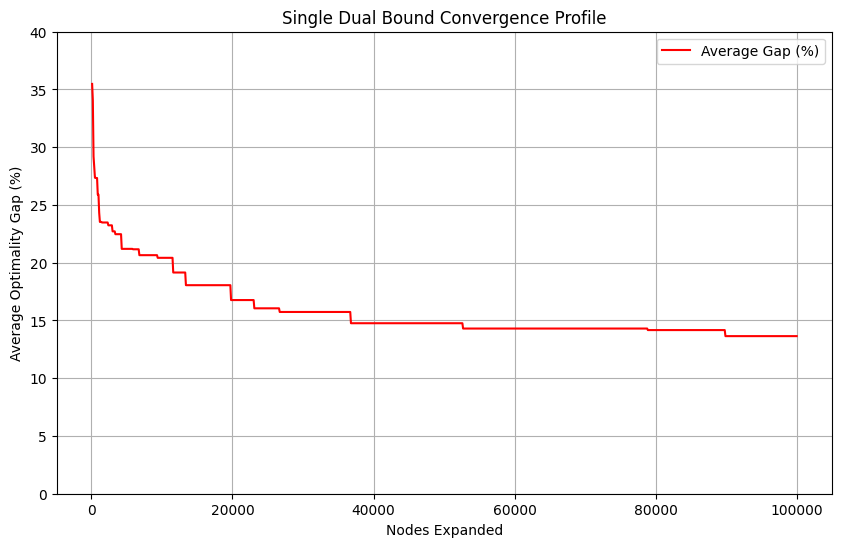

In [7]:
import pandas as pd
import numpy as np
import os
import re
import json
import glob
import math
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
LOG_DIR = "Single_Dual_Bound_Expansion_Limit_Results"
SUMMARY_OUTPUT_CSV = "Final_Single_Bound_Summary.csv"
OUTPUT_PROFILE_DIR = "Single_Bound_Profiles"
os.makedirs(OUTPUT_PROFILE_DIR, exist_ok=True)

# Data Collection Limit
COLLECTION_NODE_LIMIT = 100_000

# File with Best Known Costs (BKS)
REF_RESULTS_CSV = "CVRP_single_dual_bound_selected_results_10s_lim.csv"

def parse_solver_log_history(file_path):
    # (Same as your provided code)
    history = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            match = re.search(r"New primal bound:\s*([0-9\.\+\-eE]+),\s*expanded:\s*(\d+)", line)
            if match:
                try:
                    cost = float(match.group(1))
                    expanded = int(match.group(2))
                    history.append((expanded, cost))
                except ValueError: pass
    history.sort(key=lambda x: x[0])
    return history

def calculate_dense_gaps(history, optimal_cost, limit):
    # (Same as your provided code)
    sample_rate = 100 
    max_steps = limit // sample_rate
    dense_gaps = np.full(max_steps, np.nan)

    if not history: return dense_gaps, sample_rate 

    current_cost = float('inf')
    hist_idx = 0
    
    for i in range(max_steps):
        current_node_count = (i + 1) * sample_rate
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            if history[hist_idx][1] < current_cost:
                current_cost = history[hist_idx][1]
            hist_idx += 1
            
        if current_cost == float('inf'):
            gap = 100.0 
        else:
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
        dense_gaps[i] = gap
    return dense_gaps, sample_rate

def process_results():
    print(f"🔹 Processing Logs (Plot Limit: {COLLECTION_NODE_LIMIT})...")
    
    if not os.path.exists(REF_RESULTS_CSV):
        print(f"❌ Reference CSV missing.")
        return
    df_ref = pd.read_csv(REF_RESULTS_CSV)
    bks_map = {row['Instance'].replace(".vrp", "").strip(): row['Best Known Cost'] for _, row in df_ref.iterrows()}

    log_files = glob.glob(os.path.join(LOG_DIR, "solver_log_*.txt"))
    all_dense_gaps = []

    for log_file in log_files:
        filename = os.path.basename(log_file)
        instance_name = filename.replace("solver_log_", "").replace(".txt", "").strip()
        
        if instance_name not in bks_map: continue
        optimal_cost = bks_map[instance_name]
        
        history = parse_solver_log_history(log_file)
        
        if history:
            dense_gaps, step_size = calculate_dense_gaps(history, optimal_cost, COLLECTION_NODE_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(step_size, COLLECTION_NODE_LIMIT + 1, step_size),
                'Gap_Percent': dense_gaps
            })
            df_hist.to_csv(os.path.join(OUTPUT_PROFILE_DIR, f"gap_profile_{instance_name}.csv"), index=False)

    if all_dense_gaps:
        gap_matrix = np.vstack(all_dense_gaps)
        
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        x_axis = np.arange(100, COLLECTION_NODE_LIMIT + 1, 100)
        
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        agg_path = os.path.join(OUTPUT_PROFILE_DIR, "Single_Bound_Average_Gaps.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"✅ Aggregated data saved to {agg_path}")

        # --- PLOTTING ---
        plt.figure(figsize=(10, 6))
        plt.plot(x_axis, mean_gaps, label='Average Gap (%)', color='red')
        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title('Single Dual Bound Convergence Profile')
        plt.grid(True)
        plt.legend()
        
        # --- FIX: Set Y-Axis Ticks with Step 5 ---
        # Determine max value for the Y-axis limit
        max_y = np.nanmax(mean_gaps) if len(mean_gaps) > 0 else 100
        # Round up to nearest 5
        upper_limit = math.ceil(max_y / 5) * 5 
        # Create ticks: 0, 5, 10, ... up to upper_limit
        plt.yticks(np.arange(0, upper_limit + 5, 5))
        # -----------------------------------------

        plt.savefig(os.path.join(OUTPUT_PROFILE_DIR, "convergence_plot_single.png"))
        print(f"✅ Plot saved to {OUTPUT_PROFILE_DIR}")
        plt.show() # Show plot in notebook
    else:
        print("⚠️ No valid history data found.")

if __name__ == "__main__":
    process_results()